# FASE 3 — Entrenamiento

Entrenamos `DermaCNN` con:
- `CrossEntropyLoss` ponderada por clase (desbalance)
- Optimizador `AdamW` + scheduler `CosineAnnealingLR`
- Early stopping para evitar sobreajuste
- Checkpointing del mejor modelo (por F1-Macro en validación)
- Curvas de pérdida y métricas en tiempo real

## 1. Imports y configuración

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time, os
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, confusion_matrix

# Módulos de fases anteriores
from pipeline import get_dataloaders, CLASS_NAMES, CLASS_WEIGHTS, NUM_CLASSES
from model import DermaCNN

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


## 2. Hiperparámetros

## 3. DataLoaders, Modelo, Loss, Optimizador

In [2]:
# fase3_config_v7.py
# Cambios respecto a v6:
#   1. Pesos corregidos según análisis precision/recall (ver pipeline.py)
#   2. label_smoothing=0.05 regresa (ayuda a clases con alta precisión pero bajo recall)
#   3. Mixup alpha baja de 0.3 → 0.2 (menos agresivo, dermato necesita señal limpia)
#   4. Más épocas: 100 (el modelo todavía está aprendiendo en v6)
#
# Reemplaza celdas 2, 3 y 6 del notebook. Reiniciar kernel.

from pipeline import get_dataloaders, CLASS_NAMES, CLASS_WEIGHTS, NUM_CLASSES
from model import DermaCNN
import torch
import torch.nn as nn
import numpy as np
import time
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Mixup ────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ── CONFIG ────────────────────────────────────────────────
CONFIG = {
    'batch_size'   : 64,
    'num_epochs'   : 100,      # más épocas: v6 seguía mejorando en época 80
    'lr'           : 1e-3,
    'weight_decay' : 1e-5,
    'dropout'      : 0.25,
    'patience'     : 20,       # más paciencia para 100 épocas
    'min_delta'    : 1e-4,
    'checkpoint'   : 'best_model_v7.pth',
    'num_workers'  : 0,
    'mixup_alpha'  : 0.2,      # menos agresivo que v6 (0.3)
}

# ── Setup ─────────────────────────────────────────────────
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers']
)

imgs, labels = next(iter(train_loader))
assert imgs.shape[-1] == 64, f'Error: esperado 64x64, got {imgs.shape}'
print(f'✅ Imágenes: {imgs.shape}')

model = DermaCNN(num_classes=NUM_CLASSES, dropout=CONFIG['dropout']).to(DEVICE)

class_weights_tensor = torch.FloatTensor(CLASS_WEIGHTS).to(DEVICE)

# label_smoothing=0.05 + class_weights: combinación que funcionó bien en v3
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay']
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG['lr'],
    steps_per_epoch=len(train_loader),
    epochs=CONFIG['num_epochs'],
    pct_start=0.2,
    anneal_strategy='cos'
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Device     : {DEVICE}')
print(f'Parámetros : {total_params:,}')
print(f'Checkpoint : {CONFIG["checkpoint"]}')
print(f'Épocas     : {CONFIG["num_epochs"]} (patience={CONFIG["patience"]})')
print()
print('Pesos v7: [1.20, 1.40, 1.00, 2.00, 1.10, 0.48, 0.89]')
print('  dermato[3]: 4.87→2.00  (precision era 0.12, demasiado peso generaba FP)')
print('  basal[1]:   0.78→1.40  (recall era 0.31, el modelo lo ignoraba)')
print()

# ── Funciones auxiliares ───────────────────────────────────
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            probs  = torch.softmax(logits, dim=1)
            preds  = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    avg_loss = total_loss / len(loader.dataset)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    auc  = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    return avg_loss, acc, f1, auc, all_preds, all_labels, all_probs

class EarlyStopping:
    def __init__(self, patience=20, min_delta=1e-4, path='best.pth'):
        self.patience = patience; self.min_delta = min_delta; self.path = path
        self.counter = 0; self.best_score = None; self.stop = False
    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score; self._save(model, score)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            print(f'     EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience: self.stop = True
        else:
            self._save(model, score); self.best_score = score; self.counter = 0
    def _save(self, model, score):
        torch.save(model.state_dict(), self.path)
        print(f'     ✅ Checkpoint guardado (F1={score:.4f})')

# ── LOOP DE ENTRENAMIENTO ──────────────────────────────────
history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc',
                             'train_f1','val_f1','val_auc','lr']}
early_stopping = EarlyStopping(patience=CONFIG['patience'], min_delta=CONFIG['min_delta'],
                                path=CONFIG['checkpoint'])

print('Iniciando entrenamiento v7...')
print('='*70)
start_time = time.time()

for epoch in range(1, CONFIG['num_epochs'] + 1):
    model.train()
    train_loss = 0.0
    train_preds, train_labels_ep = [], []

    pbar = tqdm(train_loader, desc=f'Epoch {epoch:02d}/{CONFIG["num_epochs"]}',
                leave=False, ncols=80)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        imgs_mix, y_a, y_b, lam = mixup_data(imgs, labels, CONFIG['mixup_alpha'])
        optimizer.zero_grad()
        logits = model(imgs_mix)
        loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_ep.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    t_loss = train_loss / len(train_loader.dataset)
    t_acc  = accuracy_score(train_labels_ep, train_preds)
    t_f1   = f1_score(train_labels_ep, train_preds, average='macro', zero_division=0)
    v_loss, v_acc, v_f1, v_auc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    current_lr = optimizer.param_groups[0]['lr']

    for k, v in zip(['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1','val_auc','lr'],
                    [t_loss, v_loss, t_acc, v_acc, t_f1, v_f1, v_auc, current_lr]):
        history[k].append(v)

    elapsed = (time.time() - start_time) / 60
    print(f'Ep {epoch:02d} | TLoss={t_loss:.4f} Tacc={t_acc:.3f} TF1={t_f1:.3f} | '
          f'VLoss={v_loss:.4f} Vacc={v_acc:.3f} VF1={v_f1:.3f} VAUC={v_auc:.3f} | '
          f'LR={current_lr:.2e} | {elapsed:.1f}min')

    early_stopping(v_f1, model)
    if early_stopping.stop:
        print(f'\n⛔ Early stopping en época {epoch}')
        break

total_time = (time.time() - start_time) / 60
print('='*70)
print(f'Entrenamiento finalizado en {total_time:.1f} min')
print(f'Mejor F1-Macro en validación: {early_stopping.best_score:.4f}')

Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
✅ Imágenes: torch.Size([64, 3, 64, 64])
Device     : cuda
Parámetros : 495,032
Checkpoint : best_model_v7.pth
Épocas     : 100 (patience=20)

Pesos v7: [1.20, 1.40, 1.00, 2.00, 1.10, 0.48, 0.89]
  dermato[3]: 4.87→2.00  (precision era 0.12, demasiado peso generaba FP)
  basal[1]:   0.78→1.40  (recall era 0.31, el modelo lo ignoraba)

Iniciando entrenamiento v7...


Ep 01 | TLoss=1.8838 Tacc=0.248 TF1=0.176 | VLoss=1.7463 Vacc=0.511 VF1=0.302 VAUC=0.794 | LR=4.59e-05 | 0.6min
     ✅ Checkpoint guardado (F1=0.3023)


Ep 02 | TLoss=1.7940 Tacc=0.333 TF1=0.218 | VLoss=1.6702 Vacc=0.532 VF1=0.305 VAUC=0.830 | LR=6.35e-05 | 1.3min
     ✅ Checkpoint guardado (F1=0.3055)


Ep 03 | TLoss=1.7365 Tacc=0.355 TF1=0.230 | VLoss=1.6277 Vacc=0.534 VF1=0.295 VAUC=0.845 | LR=9.24e-05 | 1.9min
     EarlyStopping: 1/20


Ep 04 | TLoss=1.6923 Tacc=0.374 TF1=0.234 | VLoss=1.5828 Vacc=0.574 VF1=0.319 VAUC=0.869 | LR=1.32e-04 | 2.5min
     ✅ Checkpoint guardado (F1=0.3195)


...

Ep 67 | TLoss=1.2056 Tacc=0.452 TF1=0.362 | VLoss=1.1744 Vacc=0.654 VF1=0.520 VAUC=0.892 | LR=3.64e-04 | 42.0min
     EarlyStopping: 16/20


Ep 68 | TLoss=1.2299 Tacc=0.512 TF1=0.446 | VLoss=1.1636 Vacc=0.661 VF1=0.508 VAUC=0.901 | LR=3.45e-04 | 42.7min
     EarlyStopping: 17/20


Ep 69 | TLoss=1.2044 Tacc=0.463 TF1=0.375 | VLoss=1.1711 Vacc=0.652 VF1=0.518 VAUC=0.896 | LR=3.27e-04 | 43.3min
     EarlyStopping: 18/20


Ep 70 | TLoss=1.1876 Tacc=0.473 TF1=0.389 | VLoss=1.1446 Vacc=0.672 VF1=0.523 VAUC=0.905 | LR=3.08e-04 | 43.9min
     EarlyStopping: 19/20


Ep 71 | TLoss=1.1832 Tacc=0.508 TF1=0.432 | VLoss=1.1463 Vacc=0.671 VF1=0.539 VAUC=0.907 | LR=2.91e-04 | 44.5min
     EarlyStopping: 20/20

⛔ Early stopping en época 71
Entrenamiento finalizado en 44.5 min
Mejor F1-Macro en validación: 0.5434


## 4. Funciones de evaluación

In [3]:
def evaluate(model, loader, criterion, device):
    """
    Evalúa el modelo en un dataloader.
    Retorna: loss, accuracy, f1_macro, auc_macro, all_preds, all_labels, all_probs
    """
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []
    all_probs  = []   # probabilidades para AUC

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)

            probs  = torch.softmax(logits, dim=1)
            preds  = probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    auc      = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    return avg_loss, acc, f1, auc, all_preds, all_labels, all_probs


print('✅ Función evaluate() definida')

✅ Función evaluate() definida


## 5. Early Stopping

In [4]:
class EarlyStopping:
    """
    Detiene el entrenamiento si la métrica de validación
    no mejora por `patience` épocas consecutivas.
    Guarda el mejor modelo automáticamente.
    """
    def __init__(self, patience=12, min_delta=1e-4, path='best_model.pth', verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path
        self.verbose    = verbose
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self._save(model, score)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'     EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True
        else:
            self._save(model, score)
            self.best_score = score
            self.counter    = 0

    def _save(self, model, score):
        torch.save(model.state_dict(), self.path)
        if self.verbose:
            print(f'     ✅ Checkpoint guardado (F1={score:.4f})')


print('✅ EarlyStopping definido')

✅ EarlyStopping definido


## 6. Loop de Entrenamiento

## 7. Curvas de Entrenamiento

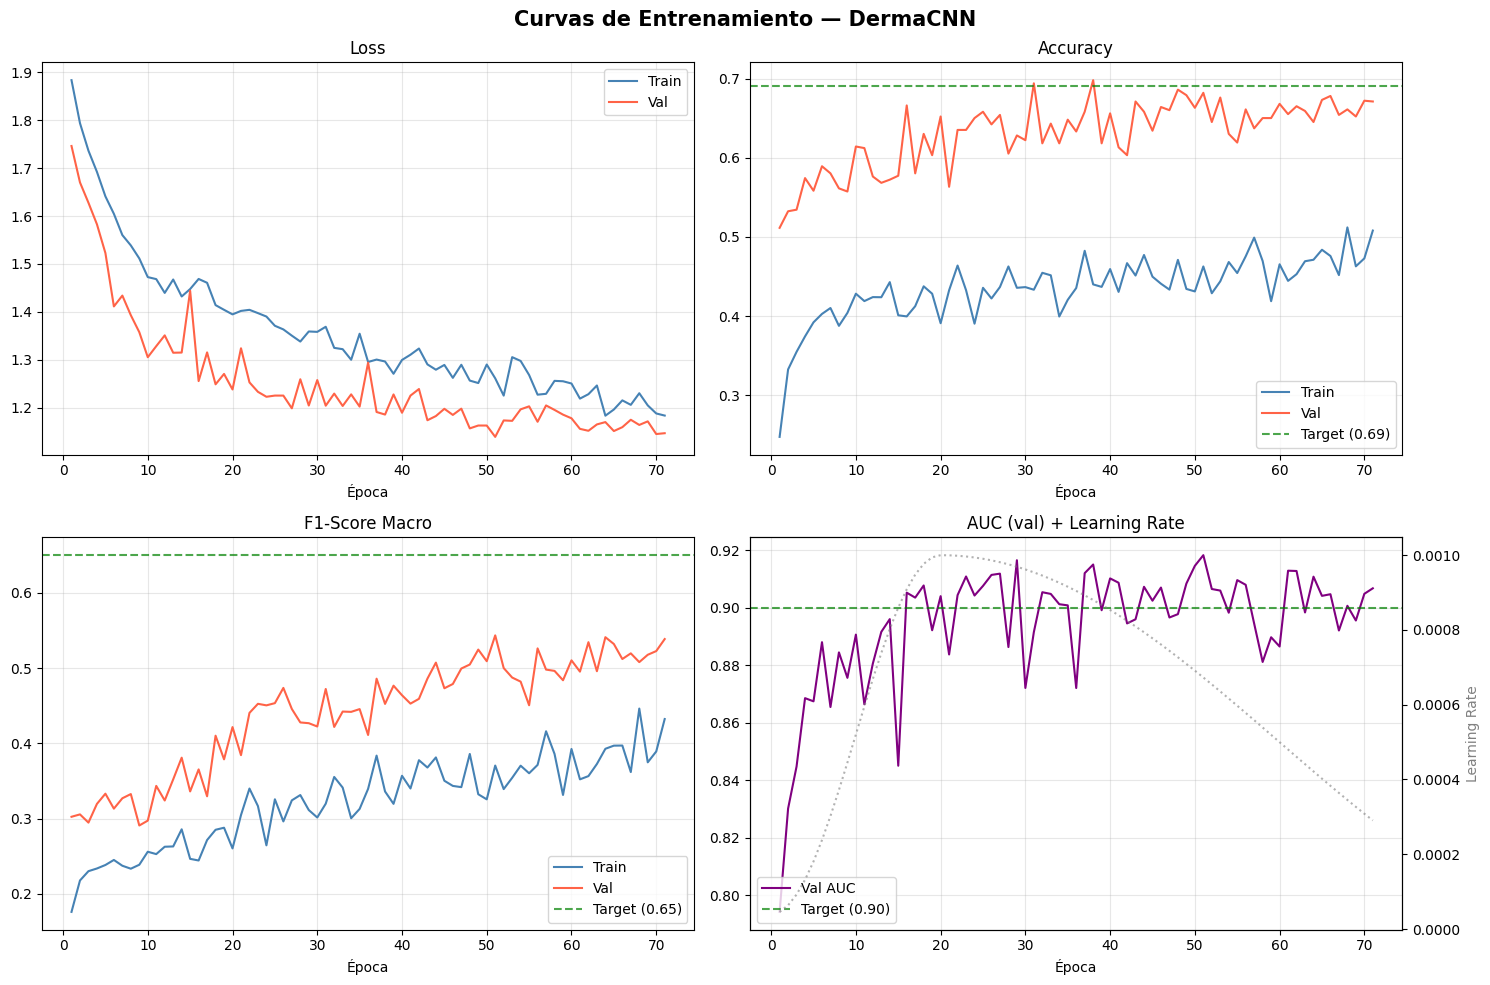

✅ Guardado: curvas_entrenamiento.png


In [9]:
epochs_ran = len(history['train_loss'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Curvas de Entrenamiento — DermaCNN', fontsize=15, fontweight='bold')

# Loss
ax = axes[0][0]
ax.plot(ep_range, history['train_loss'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_loss'],   label='Val',   color='tomato')
ax.set_title('Loss')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# Accuracy
ax = axes[0][1]
ax.plot(ep_range, history['train_acc'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_acc'],   label='Val',   color='tomato')
ax.axhline(0.69, color='green', linestyle='--', alpha=0.7, label='Target (0.69)')
ax.set_title('Accuracy')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# F1-Macro
ax = axes[1][0]
ax.plot(ep_range, history['train_f1'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_f1'],   label='Val',   color='tomato')
ax.axhline(0.65, color='green', linestyle='--', alpha=0.7, label='Target (0.65)')
ax.set_title('F1-Score Macro')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# AUC + LR
ax = axes[1][1]
ax.plot(ep_range, history['val_auc'], label='Val AUC', color='purple')
ax.axhline(0.90, color='green', linestyle='--', alpha=0.7, label='Target (0.90)')
ax2 = ax.twinx()
ax2.plot(ep_range, history['lr'], color='gray', linestyle=':', alpha=0.6, label='LR')
ax2.set_ylabel('Learning Rate', color='gray')
ax.set_title('AUC (val) + Learning Rate')
ax.set_xlabel('Época')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: curvas_entrenamiento.png')

## 8. Evaluación Final en Test Set

In [10]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load(CONFIG['checkpoint'], map_location=DEVICE))
print(f'Modelo cargado desde: {CONFIG["checkpoint"]}')

# Evaluar en Test Set
test_loss, test_acc, test_f1, test_auc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

print()
print('='*50)
print('  RESULTADOS FINALES — TEST SET')
print('='*50)

TARGETS = {'Accuracy': 0.69, 'AUC': 0.90, 'F1-Macro': 0.65}
results  = {'Accuracy': test_acc, 'AUC': test_auc, 'F1-Macro': test_f1}

for metric, value in results.items():
    target = TARGETS[metric]
    status = 'ok -' if value >= target else 'X'
    print(f'  {status} {metric:<12}: {value:.4f}  (target ≥ {target})')

print('='*50)
all_pass = all(results[m] >= TARGETS[m] for m in TARGETS)
print(f'  {"APROBADO" if all_pass else "AÚN NO CUMPLE"}')
print('='*50)

C:\Users\isape\AppData\Local\Temp\ipykernel_26616\3200187190.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CONFIG['checkpoint'], map_l

Modelo cargado desde: best_model_v7.pth

  RESULTADOS FINALES — TEST SET
  ok - Accuracy    : 0.6933  (target ≥ 0.69)
  ok - AUC         : 0.9275  (target ≥ 0.9)
  X F1-Macro    : 0.5296  (target ≥ 0.65)
  AÚN NO CUMPLE


## 9. Matriz de Confusión

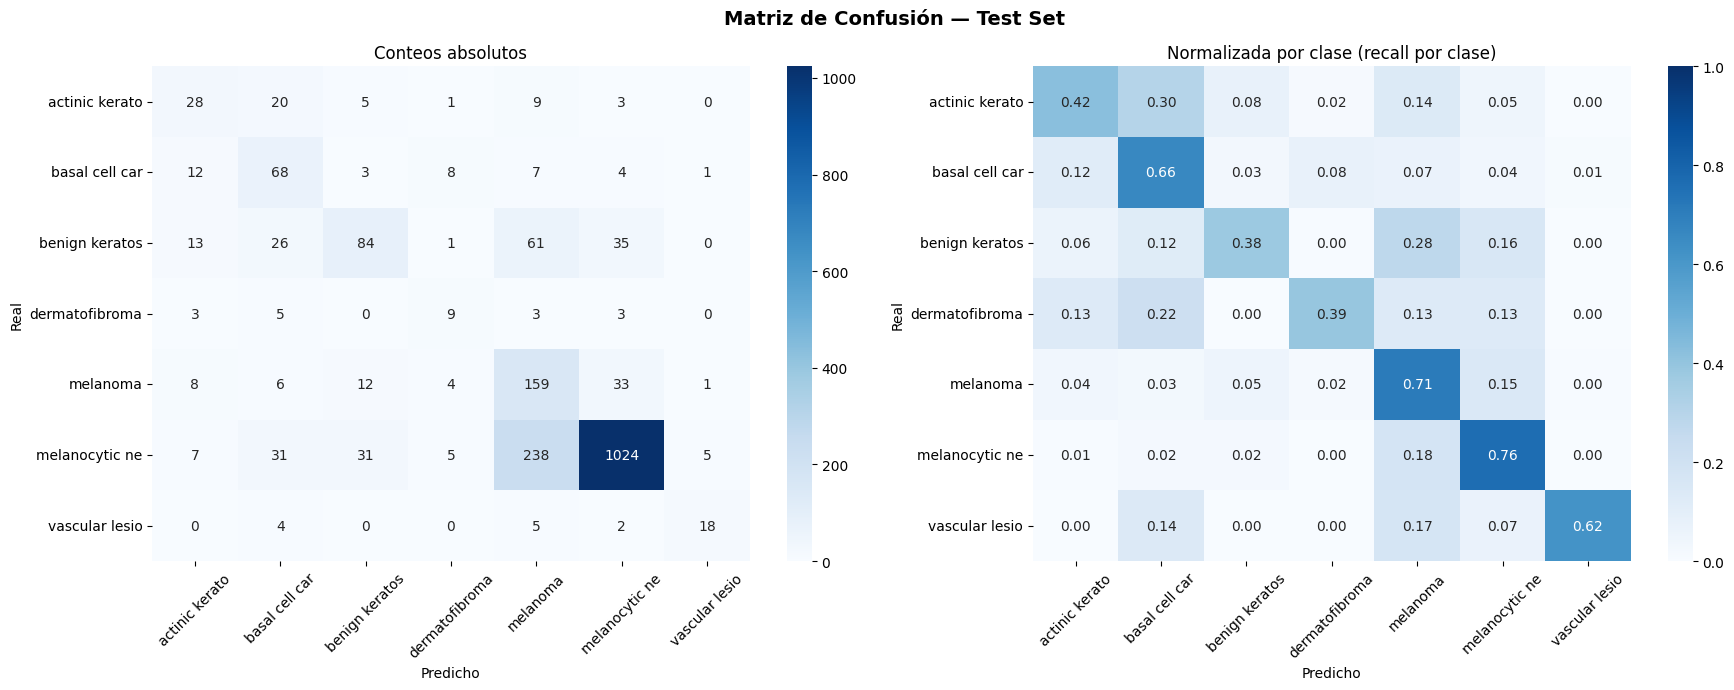

✅ Guardado: confusion_matrix.png

Reporte por clase:
                                                 precision    recall  f1-score   support

actinic keratoses and intraepithelial carcinoma       0.39      0.42      0.41        66
                           basal cell carcinoma       0.42      0.66      0.52       103
                  benign keratosis-like lesions       0.62      0.38      0.47       220
                                 dermatofibroma       0.32      0.39      0.35        23
                                       melanoma       0.33      0.71      0.45       223
                               melanocytic nevi       0.93      0.76      0.84      1341
                               vascular lesions       0.72      0.62      0.67        29

                                       accuracy                           0.69      2005
                                      macro avg       0.53      0.56      0.53      2005
                                   weighted avg       0

In [11]:
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizada por fila

short_names = [n[:14] for n in CLASS_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión — Test Set', fontsize=14, fontweight='bold')

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=axes[0])
axes[0].set_title('Conteos absolutos')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalizada por clase (recall por clase)')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: confusion_matrix.png')

# Métricas por clase
from sklearn.metrics import classification_report
print('\nReporte por clase:')
print(classification_report(test_labels, test_preds,
      target_names=CLASS_NAMES, zero_division=0))

## 11. Guardar artefactos para Fase 4

In [8]:
import pickle

# Guardar resultados del test para usar en Fase 4 (Grad-CAM)
artefactos = {
    'test_preds' : test_preds,
    'test_labels': test_labels,
    'test_probs' : test_probs,
    'history'    : history,
    'test_acc'   : test_acc,
    'test_f1'    : test_f1,
    'test_auc'   : test_auc,
}

with open('test_results.pkl', 'wb') as f:
    pickle.dump(artefactos, f)

print('Archivos listos para Fase 4:')
print('  best_model.pth    — pesos del mejor modelo')
print('  test_results.pkl  — métricas y predicciones del test set')
print('  curvas_entrenamiento.png — para el reporte IEEE')
print('  confusion_matrix.png    — para el reporte IEEE')
print()
print('✅ Fase 3 completa — listo para Fase 4: Grad-CAM')

Archivos listos para Fase 4:
  best_model.pth    — pesos del mejor modelo
  test_results.pkl  — métricas y predicciones del test set
  curvas_entrenamiento.png — para el reporte IEEE
  confusion_matrix.png    — para el reporte IEEE

✅ Fase 3 completa — listo para Fase 4: Grad-CAM


## ✅ Resumen Fase 3

| Decisión | Justificación |
|----------|---------------|
| `AdamW` | Mejor regularización que Adam estándar (weight decay separado) |
| `CosineAnnealingLR` | Evita mínimos locales — baja LR suavemente |
| `CrossEntropyLoss(weight=...)` | Segunda línea de defensa contra desbalance |
| Gradient clipping (norm=1.0) | Evita explosión de gradientes en las fusiones no lineales |
| Early stopping en F1-Macro | Métrica más representativa para datasets desbalanceados |
| Checkpoint del mejor modelo | Evita sobreajuste al final del entrenamiento |

**Siguiente paso → Fase 4: Evaluación + Grad-CAM (XAI)**